# Métricas relacionales sobre el grafo Cora

## Objetivo

En el notebook anterior se realizó una exploración inicial del conjunto de datos Cora y se construyó el grafo de citaciones correspondiente. Cada nodo del grafo representa un artículo científico y cada arista representa una relación de citación entre artículos.

El objetivo de este notebook es extraer características relacionales de los nodos mediante técnicas de análisis de redes. Estas características permitirán describir la posición y relevancia de cada artículo dentro de la estructura del grafo.

En particular, se calcularán diversas métricas relacionales como el grado, distintas medidas de centralidad, el coeficiente de agrupamiento (clustering coefficient), PageRank y la pertenencia a comunidades. Posteriormente, estas métricas se utilizarán como variables de entrada para los modelos de clasificación que se desarrollarán en fases posteriores del proyecto.

Al finalizar este notebook se obtendrá un conjunto de datos enriquecido donde cada artículo estará representado mediante sus propiedades relacionales y su categoría temática asociada.

Se seguirá el siguiente orden:
1. Introducción
2. Carga de datos
3. Reconstrucción del grafo
4. Degree y Degree Centrality
5. Betweenness Centrality
6. Closeness Centrality
7. Clustering Coefficient
8. PageRank
9. Detección de comunidades (Louvain)
10. Construcción del DataFrame final
11. Conclusiones

## Carga de los datos

Se cargan los ficheros originales del conjunto de datos Cora. El fichero `cora.content` contiene la información de los artículos y sus atributos, mientras que `cora.cites` almacena las relaciones de citación entre ellos.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [5]:
contenido = pd.read_csv("../data/raw/cora.content", sep="\t", header=None)
contenido.head()
# la columna 0 se corresponde al id del nodo, las columnas 1 a 1433 corresponden al los atriibutos 
# de palabra y la columna 1434 se corresponde a la clase a la que pertenece cada nodo

,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [6]:
citas = pd.read_csv("../data/raw/cora.cites", sep="\t", header=None)
citas.head()
# primera columna es el articulo citado y la segunda el que lo cita 

,0,1
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


A continuación, hacemos el mismo renombrado que en el notebook anterior.

In [7]:
num_features = contenido.shape[1] - 2 # nos da el numero de columnas de las palabras

columnas = ["articulo_id"] + [f"palabra_{i}" for i in range(num_features)] + ["clase"]

contenido.columns = columnas

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [8]:
citas.columns = ["articulo_citado_id", "articulo_citante_id"]

citas.head()

,articulo_citado_id,articulo_citante_id
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## Reconstrucción del grafo

A partir de las relaciones de citación se reconstruye el grafo utilizado en el análisis. Se empleará principalmente una versión no dirigida del grafo para el cálculo de las métricas relacionales.

In [11]:
G_directed = nx.from_pandas_edgelist(
    citas,
    source="articulo_citante_id",
    target="articulo_citado_id",
    create_using=nx.DiGraph()
)

print("Número de nodos:", G_directed.number_of_nodes())
print("Número de aristas:", G_directed.number_of_edges())

Número de nodos: 2708
Número de aristas: 5429


In [12]:
for _, fila in contenido.iterrows():

    articulo = fila["articulo_id"]

    G_directed.nodes[articulo]["clase"] = fila["clase"]

In [13]:
primer_nodo = list(G_directed.nodes())[0]

print(G_directed.nodes[primer_nodo])

{'clase': 'Genetic_Algorithms'}


In [14]:
G = G_directed.to_undirected()

In [15]:
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

Nodos: 2708
Aristas: 5278


## Degree y Degree Centrality

El grado de un nodo representa el número de conexiones que tiene con otros nodos del grafo. En el contexto del conjunto de datos Cora, el grado de un artículo indica cuántas relaciones de citación mantiene con otros artículos de la red.

Por otro lado, la centralidad de grado (Degree Centrality) es una versión normalizada del grado que permite comparar la importancia relativa de los nodos dentro de la red. Los nodos con valores elevados suelen ocupar posiciones más conectadas y potencialmente más relevantes dentro de la estructura del grafo.

Estas métricas constituyen una primera aproximación a la caracterización relacional de los artículos científicos.


In [16]:
degree = dict(G.degree())

print("Número de nodos analizados:", len(degree))

Número de nodos analizados: 2708


Algunos ejemplos:

In [17]:
list(degree.items())[:10]

[(1033, 5),
 (35, 168),
 (103482, 6),
 (103515, 11),
 (1050679, 4),
 (1103960, 5),
 (1103985, 2),
 (1109199, 3),
 (1112911, 4),
 (1113438, 5)]

Estadísticas del degree:

In [19]:
degree_series = pd.Series(degree)

degree_series.describe()

count    2708.000000
mean        3.898080
std         5.228784
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       168.000000
dtype: float64

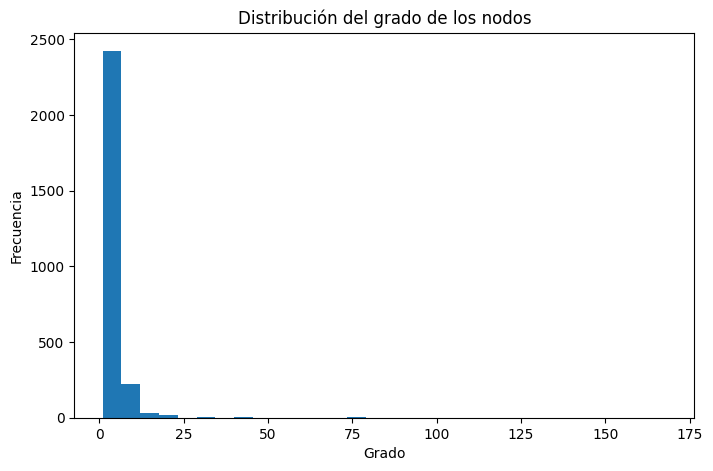

In [20]:
plt.figure(figsize=(8,5))

plt.hist(degree_series, bins=30)

plt.title("Distribución del grado de los nodos")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")

plt.savefig("../reports/degree_histograma.png")
plt.show()

Ahora, vamos a calcular la versión normalizada, siguiendo el mismo proceso.

In [21]:
degree_centrality = nx.degree_centrality(G)

print("Número de nodos analizados:",
      len(degree_centrality))

Número de nodos analizados: 2708


In [22]:
degree_centrality_series = pd.Series(
    degree_centrality
)

degree_centrality_series.describe()

count    2708.000000
mean        0.001440
std         0.001932
min         0.000369
25%         0.000739
50%         0.001108
75%         0.001847
max         0.062061
dtype: float64

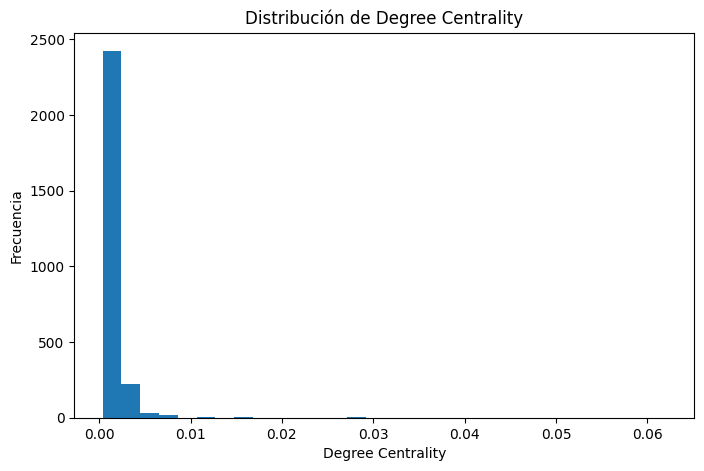

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    degree_centrality_series,
    bins=30
)

plt.title(
    "Distribución de Degree Centrality"
)

plt.xlabel("Degree Centrality")
plt.ylabel("Frecuencia")

plt.savefig("../reports/central_degree_histograma.png")
plt.show()

A partir de aquí empezaremos a construir el dataset final.

In [25]:
metricas_df = pd.DataFrame({
    "articulo_id": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "degree_centrality":
        [degree_centrality[n] for n in G.nodes()]
})
metricas_df.head()

,articulo_id,degree,degree_centrality
0,1033,5,0.001847
1,35,168,0.062061
2,103482,6,0.002216
3,103515,11,0.004064
4,1050679,4,0.001478


### Interpretación del grado

La distribución del grado presenta una marcada asimetría. Aunque el grado medio es aproximadamente 3.9 conexiones por nodo, la mayoría de los artículos poseen muy pocas relaciones de citación. De hecho, el 75% de los nodos tienen un grado igual o inferior a 5.

Sin embargo, existen algunos artículos excepcionalmente conectados, alcanzando un grado máximo de 168. Este comportamiento es característico de las redes de citación científicas, donde un reducido número de publicaciones actúan como referencias importantes y concentran un gran número de conexiones dentro de la red.
